# Phase 1 — Exploratory Data Analysis (EDA)
## Credit Risk Scoring Model | German Credit Dataset

EDA is the first thing you do before any modeling. Think of it as a doctor examining a patient before prescribing treatment.  
We need to understand:
- What the data looks like (shape, types, nulls)
- How balanced our target classes are
- How features are distributed
- Which features seem related to credit risk

This notebook answers all of those questions.

## Step 1 — Imports

We import everything we need upfront. `warnings.filterwarnings('ignore')` keeps the output clean — suppresses deprecation notices that don't affect our work.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Makes plots look clean and consistent throughout the notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("Imports successful.")

Imports successful.


## Step 2 — Load the Raw Data

The raw file has **no headers** — just space-separated values with coded column names.  
We manually assign column names based on the `german.doc` documentation.

**Why name columns properly?**  
Code like `A11`, `A34` is meaningless. `checking_status`, `credit_history` tells you exactly what you're looking at. Good column names = readable code = fewer bugs.

In [2]:
column_names = [
    "checking_status",       # Balance in checking account
    "duration",              # Loan duration in months
    "credit_history",        # Past repayment behavior
    "purpose",               # What the loan is for
    "credit_amount",         # Loan amount in DM
    "savings_status",        # Savings account balance
    "employment",            # Years at current job
    "installment_commitment",# Installment as % of income
    "personal_status",       # Sex + marital status
    "other_parties",         # Co-applicant or guarantor
    "residence_since",       # Years at current address
    "property_magnitude",    # Most valuable property owned
    "age",                   # Age in years
    "other_payment_plans",   # Other active installment plans
    "housing",               # Rent / own / free
    "existing_credits",      # No. of credits at this bank
    "job",                   # Skill level of employment
    "num_dependents",        # No. of financial dependents
    "own_telephone",         # Has registered telephone
    "foreign_worker",        # Is a foreign worker
    "target"                 # 1 = Good Credit, 2 = Bad Credit
]

df = pd.read_csv(
    "../data/raw/german.data",
    sep=" ",
    header=None,
    names=column_names
)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 1000 rows, 21 columns


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## Step 3 — Basic Inspection

Before anything else, we check:
- **Shape** — how many rows and columns?
- **dtypes** — are numeric columns stored as numbers? Categorical as objects?
- **Nulls** — any missing values that need handling?
- **Describe** — summary statistics for numerical columns (min, max, mean, std)

This is a sanity check. Wrong dtypes or hidden nulls will silently break your model later.

In [3]:
print("=== Shape ===")
print(f"{df.shape[0]} rows × {df.shape[1]} columns\n")

print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No missing values found.")

=== Shape ===
1000 rows × 21 columns

=== Data Types ===
checking_status           object
duration                   int64
credit_history            object
purpose                   object
credit_amount              int64
savings_status            object
employment                object
installment_commitment     int64
personal_status           object
other_parties             object
residence_since            int64
property_magnitude        object
age                        int64
other_payment_plans       object
housing                   object
existing_credits           int64
job                       object
num_dependents             int64
own_telephone             object
foreign_worker            object
target                     int64
dtype: object

=== Missing Values ===
No missing values found.


In [4]:
print("=== Numerical Summary Statistics ===")
df.describe().T

=== Numerical Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_commitment,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
num_dependents,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0
target,1000.0,1.300,0.458487,1.0,1.0,1.0,2.00,2.0


## Step 4 — Class Balance Check

**Why this matters:**  
If 95% of applicants are "Good" and 5% are "Bad", a model that predicts "Good" for everyone gets 95% accuracy — but it's completely useless for the bank.

This is called **class imbalance** and it's one of the most common problems in real-world classification.  
We expect roughly 70% Good / 30% Bad in this dataset. If it's worse than that, we'll fix it in Phase 2 using **SMOTE**.

=== Class Distribution ===
Good Credit (1): 700 (70.0%)
Bad Credit  (2): 300 (30.0%)


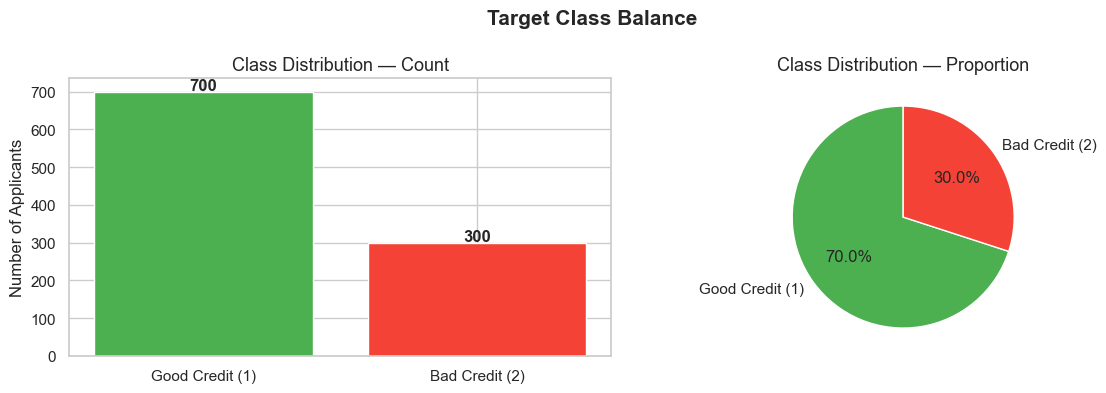

In [5]:
class_counts = df['target'].value_counts()
class_pct = df['target'].value_counts(normalize=True) * 100

print("=== Class Distribution ===")
print(f"Good Credit (1): {class_counts[1]} ({class_pct[1]:.1f}%)")
print(f"Bad Credit  (2): {class_counts[2]} ({class_pct[2]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Good Credit (1)', 'Bad Credit (2)'], class_counts.values, color=['#4CAF50', '#F44336'])
axes[0].set_title('Class Distribution — Count', fontsize=13)
axes[0].set_ylabel('Number of Applicants')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Good Credit (1)', 'Bad Credit (2)'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Class Distribution — Proportion', fontsize=13)

plt.suptitle('Target Class Balance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Numerical Feature Distributions

We plot histograms for all numerical columns.

**Why?**
- See if values are normally distributed, skewed, or have outliers
- Skewed distributions (like `credit_amount`) may need log transformation later
- Outliers can pull model weights in the wrong direction
- Understanding the range helps us spot data entry errors

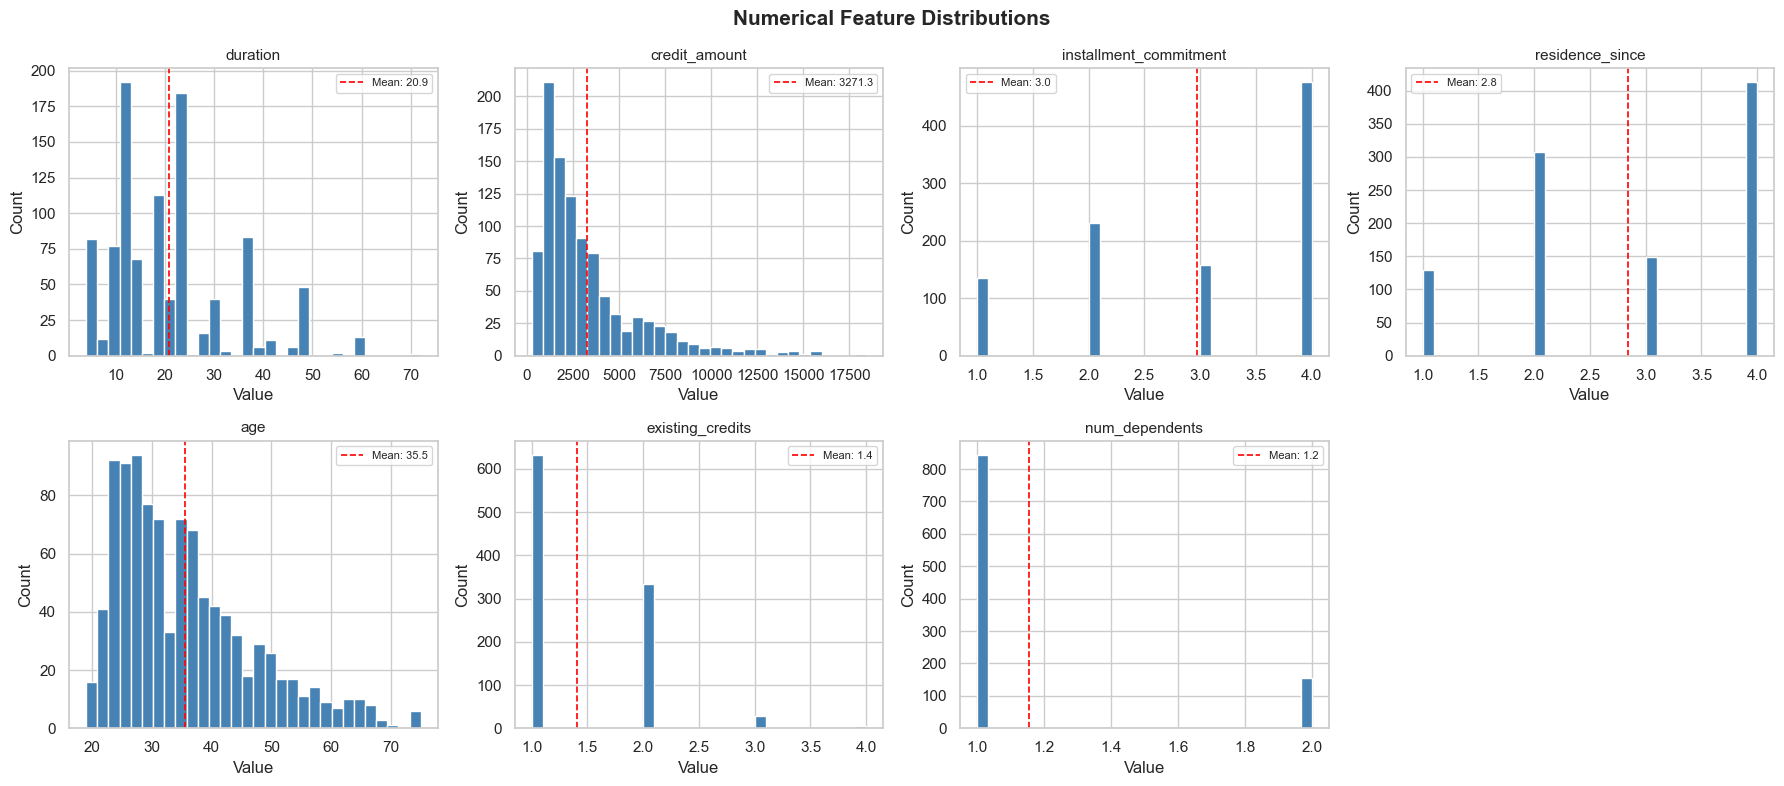

In [6]:
num_cols = ['duration', 'credit_amount', 'installment_commitment',
            'residence_since', 'age', 'existing_credits', 'num_dependents']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8)

# Hide the empty 8th subplot
axes[-1].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Numerical Features vs Target (Box Plots)

A histogram shows the overall distribution. A **box plot split by target** shows whether a feature actually separates good vs bad borrowers.

**Why box plots?**
- If the boxes for Good (1) and Bad (2) overlap a lot → feature may not be useful
- If they're clearly separated → strong signal for the model
- The median line and whiskers tell us about spread and outliers per class

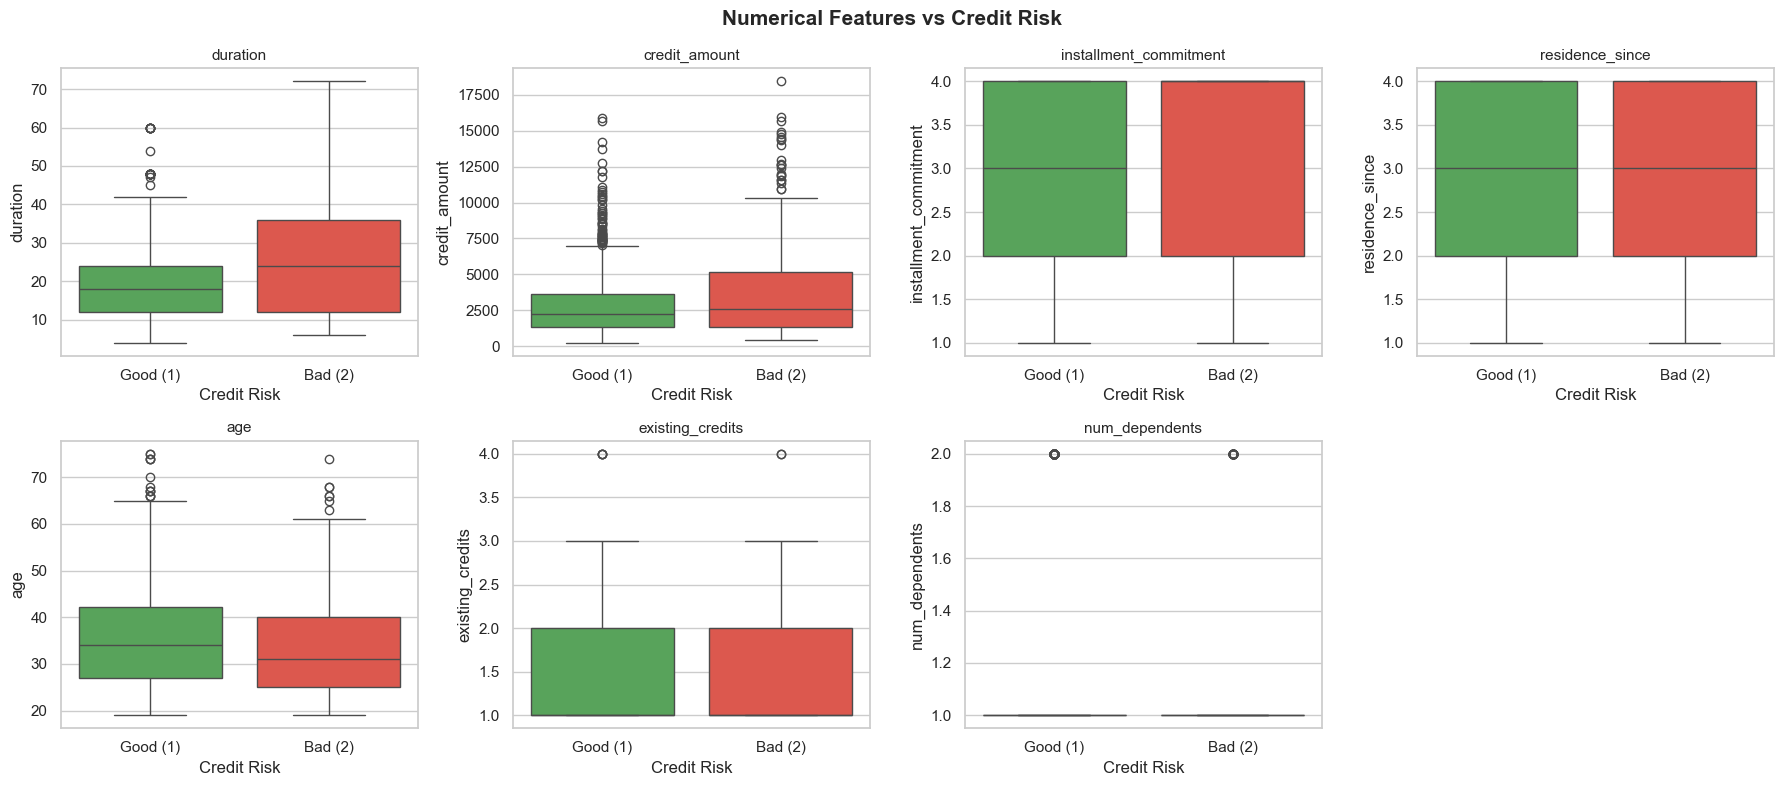

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

# Convert target to string so seaborn palette keys match
df['target_str'] = df['target'].map({1: 'Good (1)', 2: 'Bad (2)'})

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='target_str', y=col, ax=axes[i],
                palette={'Good (1)': '#4CAF50', 'Bad (2)': '#F44336'},
                order=['Good (1)', 'Bad (2)'])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Credit Risk')
    axes[i].set_ylabel(col)

axes[-1].set_visible(False)
df.drop(columns=['target_str'], inplace=True)

plt.suptitle('Numerical Features vs Credit Risk', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/boxplots_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Categorical Feature Analysis

Categorical columns contain codes like `A11`, `A32`, etc. We need to map them to readable labels before plotting.

**Why map codes to labels?**
- `A11` on a chart is meaningless. `"< 0 DM"` tells a story.
- Readable charts → better insights → better business narrative

In [8]:
# Readable label mappings based on german.doc
label_maps = {
    "checking_status": {
        "A11": "< 0 DM", "A12": "0–200 DM", "A13": ">= 200 DM", "A14": "No Account"
    },
    "credit_history": {
        "A30": "No credits/all paid", "A31": "All paid at bank",
        "A32": "Existing paid duly", "A33": "Delay in past", "A34": "Critical account"
    },
    "purpose": {
        "A40": "New car", "A41": "Used car", "A42": "Furniture",
        "A43": "Radio/TV", "A44": "Appliances", "A45": "Repairs",
        "A46": "Education", "A48": "Retraining", "A49": "Business", "A410": "Others"
    },
    "savings_status": {
        "A61": "< 100 DM", "A62": "100–500 DM", "A63": "500–1000 DM",
        "A64": ">= 1000 DM", "A65": "Unknown/None"
    },
    "employment": {
        "A71": "Unemployed", "A72": "< 1 yr", "A73": "1–4 yrs",
        "A74": "4–7 yrs", "A75": ">= 7 yrs"
    },
    "housing": {"A151": "Rent", "A152": "Own", "A153": "Free"},
    "job": {
        "A171": "Unskilled non-resident", "A172": "Unskilled resident",
        "A173": "Skilled", "A174": "Management"
    }
}

# Apply mappings to a copy for plotting only
df_plot = df.copy()
for col, mapping in label_maps.items():
    df_plot[col] = df_plot[col].map(mapping).fillna(df_plot[col])

print("Label mappings applied for plotting.")

Label mappings applied for plotting.


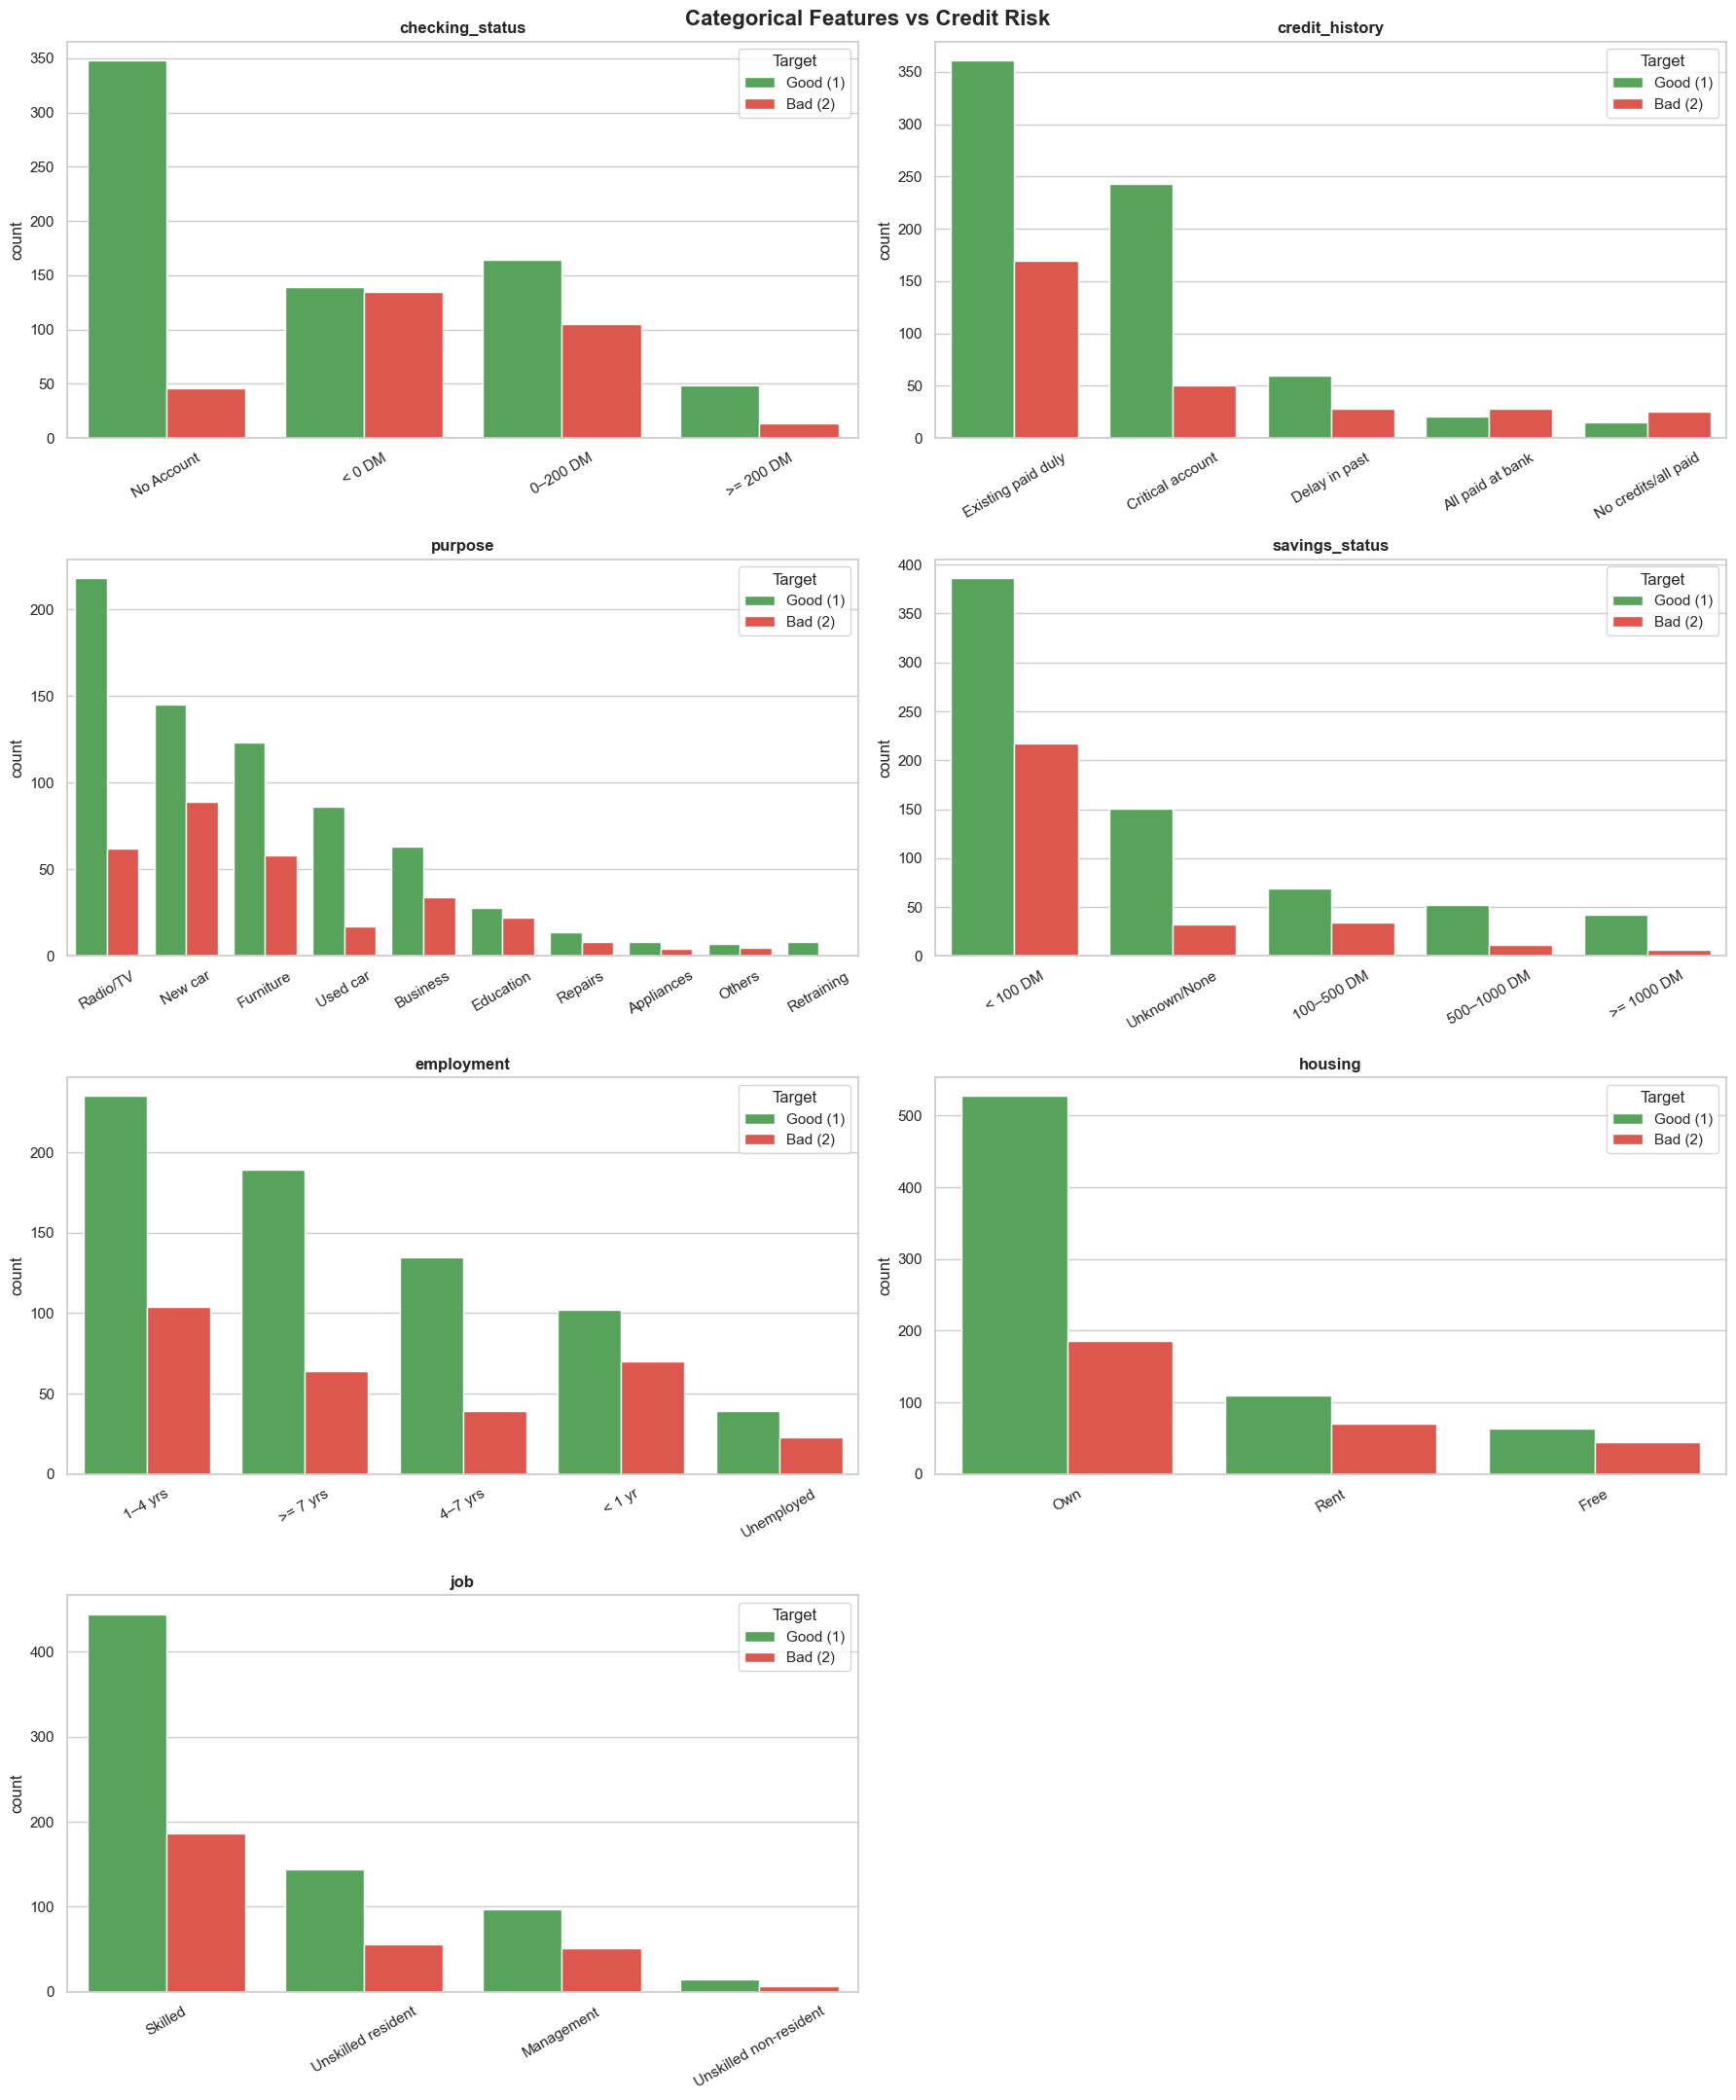

In [9]:
cat_cols = list(label_maps.keys())

fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df_plot[col].value_counts().index
    sns.countplot(data=df_plot, x=col, hue='target', ax=axes[i],
                  order=order, palette={1: '#4CAF50', 2: '#F44336'})
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Target', labels=['Good (1)', 'Bad (2)'])

axes[-1].set_visible(False)

plt.suptitle('Categorical Features vs Credit Risk', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/categorical_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Correlation Heatmap (Numerical Features)

A correlation heatmap shows how strongly pairs of numerical features are linearly related.

**Why check correlations?**
- High correlation between two features (e.g., 0.9) = they carry almost the same information → one can be dropped (reduces noise)
- High correlation between a feature and the target → strong predictor
- Helps avoid **multicollinearity**, which hurts Logistic Regression's interpretability

Note: This only works on numerical columns. Categorical correlations are handled differently (Cramér's V), which we'll explore as needed.

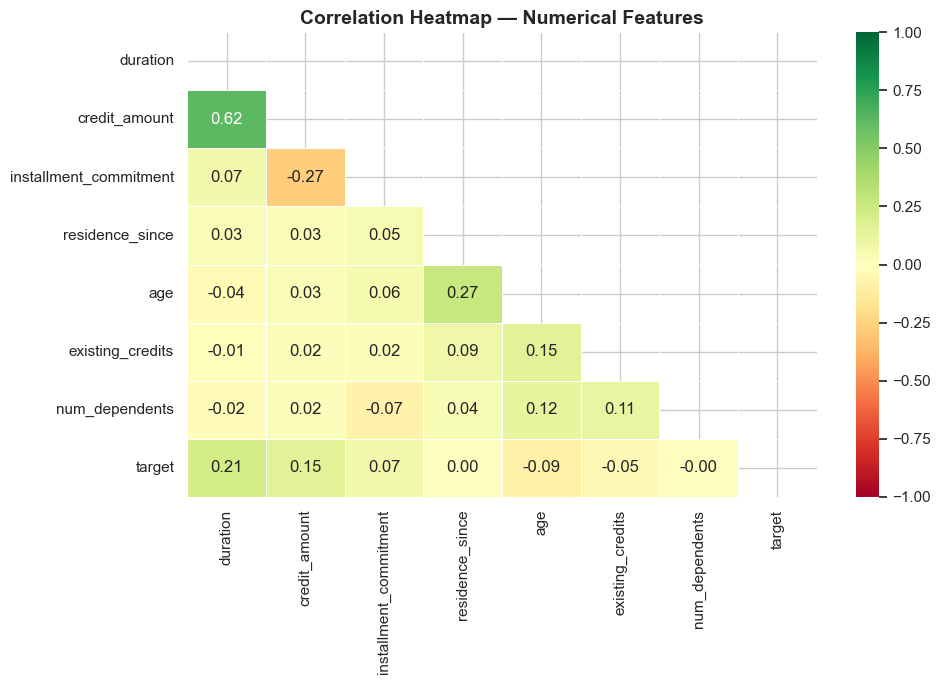

In [10]:
corr_cols = num_cols + ['target']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle (duplicate)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — Risk Breakdown by Key Features

Now we go deeper on the features most likely to drive credit risk.  
We calculate the **bad credit rate** per category — i.e., what % of applicants in each group defaulted.

**Why this is important:**
- Raw counts can be misleading (a large group looks risky just because it has more people)
- Default *rate* normalizes for group size — it's a fair comparison
- This is the kind of insight that goes directly into a business report or dashboard

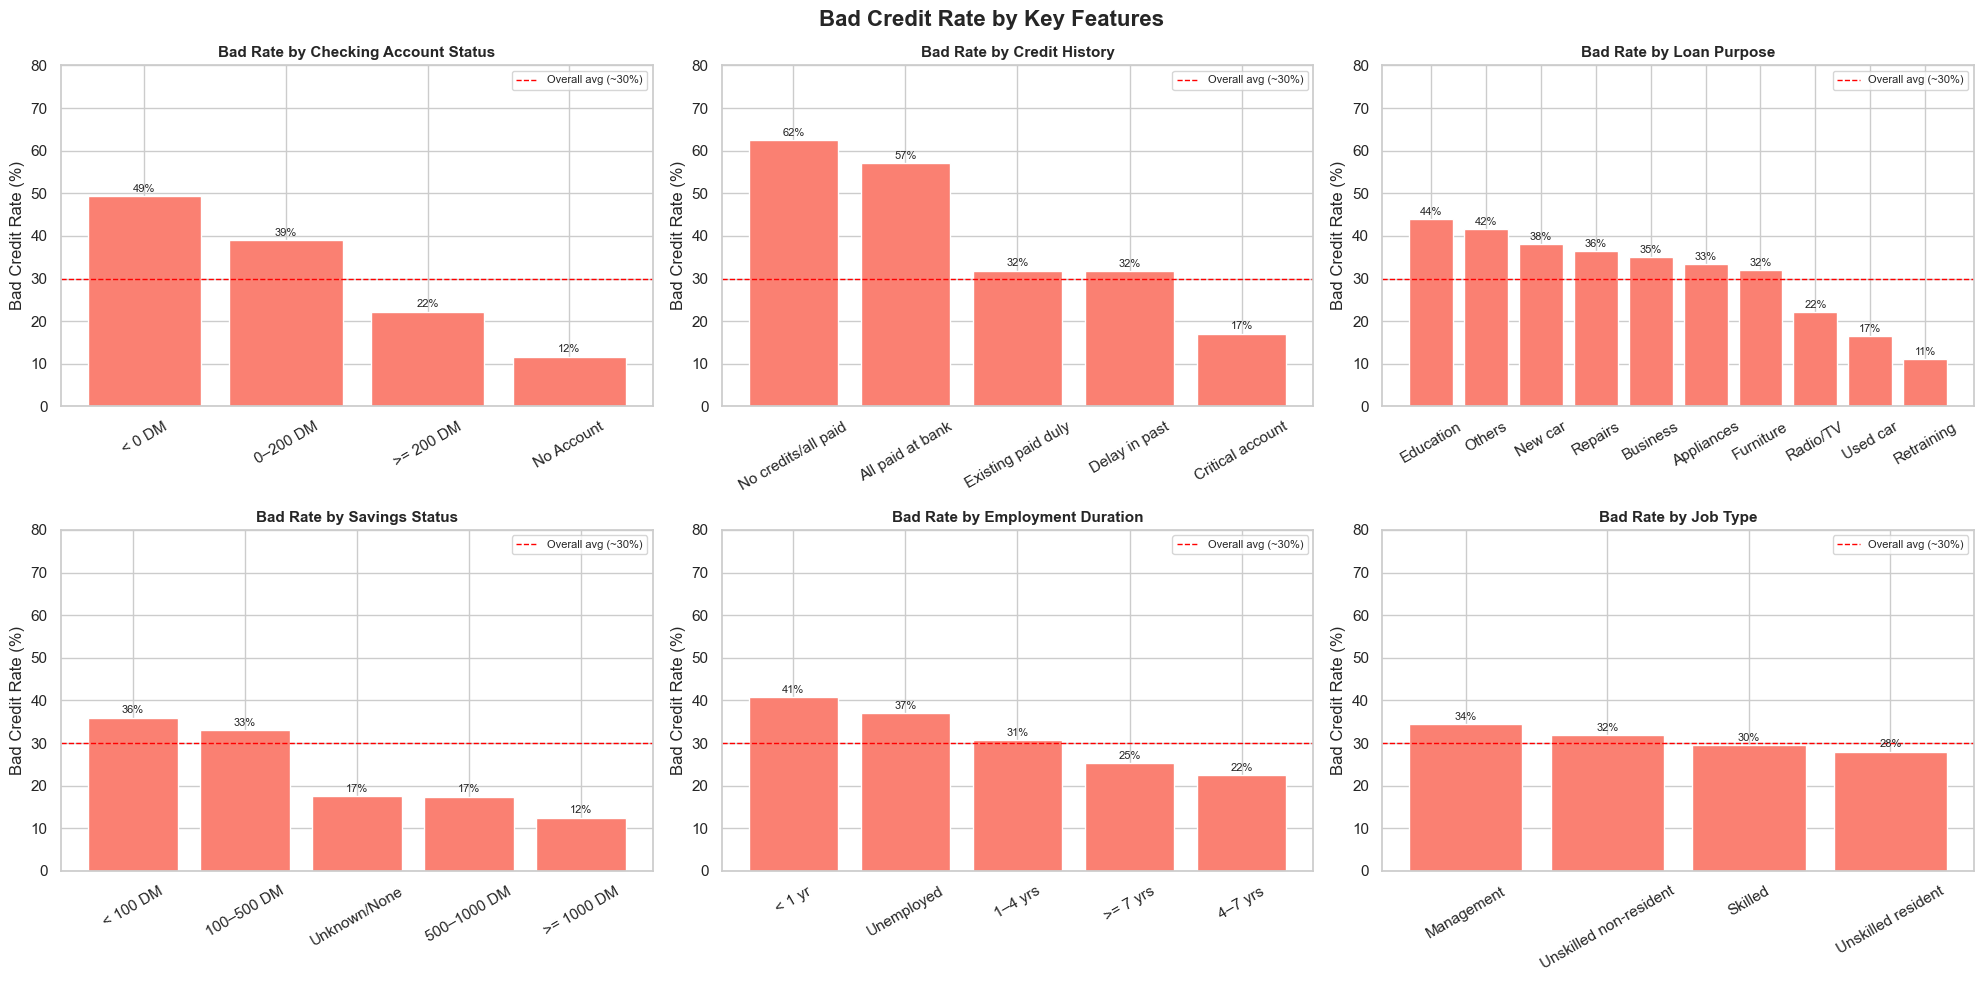

In [11]:
def plot_bad_rate(col, title, ax, use_labels=True):
    """Calculate and plot bad credit rate (%) per category."""
    source = df_plot if use_labels else df
    bad_rate = source.groupby(col)['target'].apply(
        lambda x: (x == 2).sum() / len(x) * 100
    ).sort_values(ascending=False)
    bars = ax.bar(bad_rate.index.astype(str), bad_rate.values, color='salmon', edgecolor='white')
    ax.axhline(y=30, color='red', linestyle='--', linewidth=1, label='Overall avg (~30%)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Bad Credit Rate (%)')
    ax.set_ylim(0, 80)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, bad_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.0f}%', ha='center', fontsize=8)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

plot_bad_rate('checking_status', 'Bad Rate by Checking Account Status', axes[0][0])
plot_bad_rate('credit_history',  'Bad Rate by Credit History',          axes[0][1])
plot_bad_rate('purpose',         'Bad Rate by Loan Purpose',            axes[0][2])
plot_bad_rate('savings_status',  'Bad Rate by Savings Status',          axes[1][0])
plot_bad_rate('employment',      'Bad Rate by Employment Duration',     axes[1][1])
plot_bad_rate('job',             'Bad Rate by Job Type',                axes[1][2])

plt.suptitle('Bad Credit Rate by Key Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/bad_rate_by_feature.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Age vs Credit Risk

Age is a continuous variable. Instead of a box plot, we bin it into groups to see risk by life stage.

**Why bin age?**
- Binning turns a continuous variable into a story: "young adults default more than middle-aged applicants"
- Easier to explain to a business stakeholder than a scatter plot
- These bins can also become a new feature in Phase 2

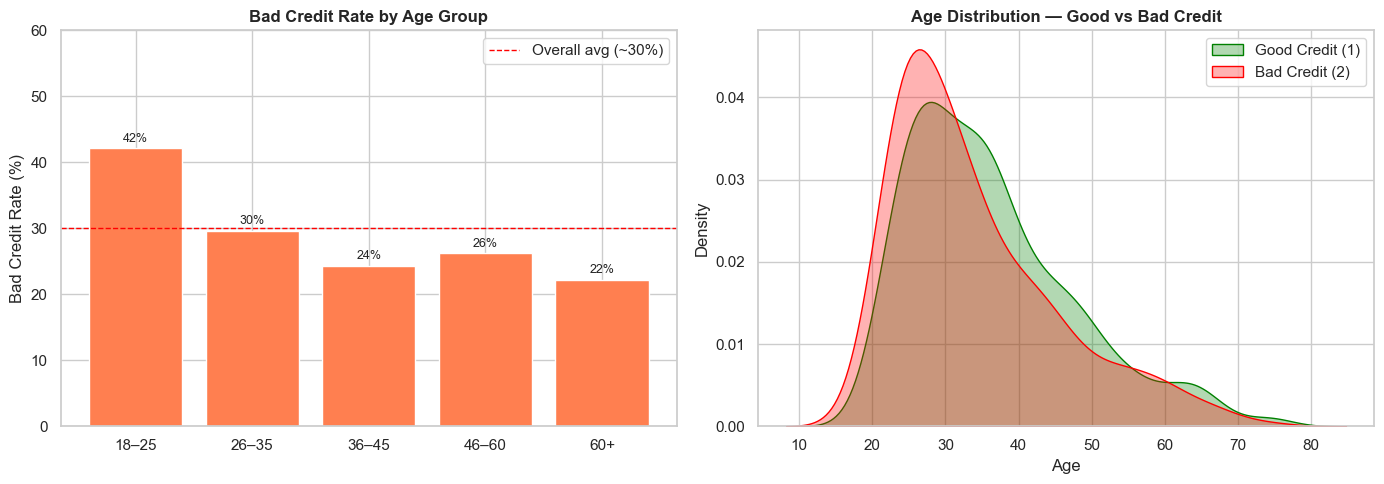

In [12]:
df['age_group'] = pd.cut(df['age'],
                          bins=[18, 25, 35, 45, 60, 100],
                          labels=['18–25', '26–35', '36–45', '46–60', '60+'])

age_risk = df.groupby('age_group', observed=True)['target'].apply(
    lambda x: (x == 2).sum() / len(x) * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bad rate by age group
axes[0].bar(age_risk.index.astype(str), age_risk.values, color='coral', edgecolor='white')
axes[0].axhline(y=30, color='red', linestyle='--', linewidth=1, label='Overall avg (~30%)')
axes[0].set_title('Bad Credit Rate by Age Group', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Bad Credit Rate (%)')
axes[0].set_ylim(0, 60)
axes[0].legend()
for i, v in enumerate(age_risk.values):
    axes[0].text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=9)

# Age distribution by target
sns.kdeplot(data=df[df['target'] == 1], x='age', ax=axes[1], label='Good Credit (1)', color='green', fill=True, alpha=0.3)
sns.kdeplot(data=df[df['target'] == 2], x='age', ax=axes[1], label='Bad Credit (2)', color='red', fill=True, alpha=0.3)
axes[1].set_title('Age Distribution — Good vs Bad Credit', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/age_vs_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# Drop helper column — it was only for this analysis
df.drop(columns=['age_group'], inplace=True)

## Step 11 — Save Clean EDA Summary

We save the raw dataframe (with proper column names) as a CSV to `data/processed/`.  
This is the starting point for Phase 2 (Feature Engineering).

**Why save it separately?**
- `data/raw/german.data` stays untouched forever
- `data/processed/german_named.csv` has our column names applied — ready to build on

In [13]:
df.to_csv('../data/processed/german_named.csv', index=False)
print("Saved: data/processed/german_named.csv")
print(f"Shape: {df.shape}")
print("\nEDA Complete. Key takeaways:")
print("  - 700 Good (70%) vs 300 Bad (30%) — moderate imbalance, SMOTE needed in Phase 2")
print("  - checking_status, credit_history, savings_status appear to be strong risk indicators")
print("  - Younger applicants (18–25) show higher default rates")
print("  - credit_amount and duration are right-skewed — may benefit from log transform")
print("  - No missing values in this dataset")

Saved: data/processed/german_named.csv
Shape: (1000, 21)

EDA Complete. Key takeaways:
  - 700 Good (70%) vs 300 Bad (30%) — moderate imbalance, SMOTE needed in Phase 2
  - checking_status, credit_history, savings_status appear to be strong risk indicators
  - Younger applicants (18–25) show higher default rates
  - credit_amount and duration are right-skewed — may benefit from log transform
  - No missing values in this dataset
